In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, silhouette_score

In [2]:
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [3]:
numeric_cols = ['Age', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)',
                'Stress_Level(1-10)', 'Days_Without_Social_Media',
                'Exercise_Frequency(week)']
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
mask = ~(((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
          (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1))
clean = df[mask].copy()

In [4]:
reg = clean.drop(columns=['User_ID']).copy()
le = LabelEncoder()
reg['Gender'] = le.fit_transform(reg['Gender'])
reg = pd.get_dummies(reg, columns=['Social_Media_Platform'], drop_first=False)

X = reg.drop(columns=['Happiness_Index(1-10)'])
y = reg['Happiness_Index(1-10)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Multiple Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(max_iter=10000),
    "Elastic Net Regression": ElasticNet(max_iter=10000)
}

Intercept: 8.840734342201365
Coefficients:
Age 0.012280444281558472
Gender 0.007616019055842814
Daily_Screen_Time(hrs) -0.039414178476839305
Sleep_Quality(1-10) 0.36624383234972674
Stress_Level(1-10) -0.46105566354077177
Days_Without_Social_Media 0.024697774969448947
Exercise_Frequency(week) 0.007783996029343782
Social_Media_Platform_Facebook 0.028993553851852323
Social_Media_Platform_Instagram -0.11350195063217663
Social_Media_Platform_LinkedIn 0.029520746827299334
Social_Media_Platform_TikTok -0.12814033731261806
Social_Media_Platform_X (Twitter) 0.08970515871111014
Social_Media_Platform_YouTube 0.09342282855452322


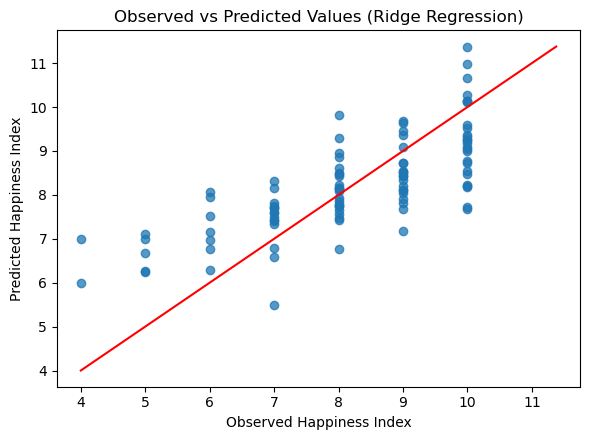

In [5]:
ridge = Ridge()
ridge.fit(X_train, y_train)
print("Intercept:", ridge.intercept_)
print("Coefficients:")
for name, coef in zip(X.columns, ridge.coef_):
    print(name, coef)

ridge_pred = ridge.predict(X_test)
plt.figure(figsize=(6, 4.5))
plt.scatter(y_test, ridge_pred, alpha=0.75)
lims = [min(y_test.min(), ridge_pred.min()), max(y_test.max(), ridge_pred.max())]
plt.plot(lims, lims, 'r-')
plt.xlabel("Observed Happiness Index")
plt.ylabel("Predicted Happiness Index")
plt.title("Observed vs Predicted Values (Ridge Regression)")
plt.tight_layout()
plt.show()

In [6]:
cls = clean.drop(columns=['User_ID']).copy()
cls['Happiness_Category'] = pd.cut(
    cls['Happiness_Index(1-10)'],
    bins=[0, 4, 7, 10],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
cls['Gender'] = LabelEncoder().fit_transform(cls['Gender'])
X_cls = pd.get_dummies(cls.drop(columns=['Happiness_Index(1-10)', 'Happiness_Category']),
                       columns=['Social_Media_Platform'], drop_first=False)
y_cls = cls['Happiness_Category']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_test_s = scaler.transform(Xc_test)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Support Vector Machine (SVM)": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200)
}

for name, clf in classifiers.items():
    clf.fit(Xc_train_s, yc_train)
    pred = clf.predict(Xc_test_s)
    print(name,
          "Accuracy=", accuracy_score(yc_test, pred),
          "Precision=", precision_score(yc_test, pred, average='weighted', zero_division=0),
          "Recall=", recall_score(yc_test, pred, average='weighted', zero_division=0),
          "F1=", f1_score(yc_test, pred, average='weighted', zero_division=0))

print(cls['Happiness_Category'].value_counts())

Logistic Regression Accuracy= 0.797979797979798 Precision= 0.781057326511872 Recall= 0.797979797979798 F1= 0.7877319051815697
K-Nearest Neighbors (KNN) Accuracy= 0.7575757575757576 Precision= 0.726040525739321 Recall= 0.7575757575757576 F1= 0.7319089512637899
Support Vector Machine (SVM) Accuracy= 0.7878787878787878 Precision= 0.7641696737822994 Recall= 0.7878787878787878 F1= 0.767188648795414
Decision Tree Accuracy= 0.7878787878787878 Precision= 0.7840745884224144 Recall= 0.7878787878787878 F1= 0.7844524830826202
Random Forest Accuracy= 0.8080808080808081 Precision= 0.7932875667429443 Recall= 0.8080808080808081 F1= 0.7996122281836567
Happiness_Category
High      359
Medium    130
Low         6
Name: count, dtype: int64


In [11]:
cluster_features = clean[['Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)','Stress_Level(1-10)', 'Days_Without_Social_Media', 'Exercise_Frequency(week)', 'Happiness_Index(1-10)']]

Z = StandardScaler().fit_transform(cluster_features)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Z)
    print("k=", k, "silhouette=", silhouette_score(Z, labels))

km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = km.fit_predict(Z)
print(cluster_features.assign(Cluster=labels).groupby("Cluster").mean())


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 2 silhouette= 0.28292093791250705
k= 3 silhouette= 0.18617442855130623


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k= 4 silhouette= 0.18445633513571638
k= 5 silhouette= 0.18368863741024055
k= 6 silhouette= 0.1763238413737905


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


         Daily_Screen_Time(hrs)  Sleep_Quality(1-10)  Stress_Level(1-10)  \
Cluster                                                                    
0                      4.290079             7.317460            5.555556   
1                      6.804115             5.259259            7.720165   

         Days_Without_Social_Media  Exercise_Frequency(week)  \
Cluster                                                        
0                         3.234127                  2.484127   
1                         3.045267                  2.382716   

         Happiness_Index(1-10)  
Cluster                         
0                     9.492063  
1                     7.230453  
